## Plots

This module (`askcarl.plot`) is optional, and to use it, matplotlib and reportlab
need to be installed.

### Corner plots

To visualise a high-dimensional distribution, one can use a corner plot
(also known as pairs plot). These are a matrix of panels, with the
conditional (pair-wise) distribution. The diagonal are marginal distributions.
Instead of drawing scattered samples, drawing contours, corresponding 
to the probability enclosed (e.g., 99%) is informative.
To achieve this, a density estimate is needed.

Common techniques include kernel density estimate (see fastKDE, getdist, corner.py).
However, these can be slow.


### Corner plots of GMMs

Here, we show how to use Gaussian Mixture Modesl (GMMs) to build a corner plot.

First, we build a demo GMM from samples:

In [1]:
import numpy as np
import time
from askcarl.lightgmm import LightBaggingGMM

ndim = 6

X = np.vstack([
    np.random.multivariate_normal(0 + np.arange(ndim), np.eye(ndim), 3000 * ndim),
    np.random.multivariate_normal(3 + np.arange(ndim), np.eye(ndim), 3000 * ndim)
])

t0 = time.time()
lgmm = LightBaggingGMM(n_gmms=20, n_components=10)
lgmm.fit(X)
print(f'LightBaggingGMM fit of {len(X)} data points: {time.time() - t0:.2f}s')
gmm = lgmm.to_sklearn()


LightBaggingGMM fit of 36000 data points: 0.49s


We can verify that the distribution is well-approximated by the GMM,
by plotting the training points and points sampled from the GMM.
We can use corner.py to plot both:

sample + corner: 1.22s


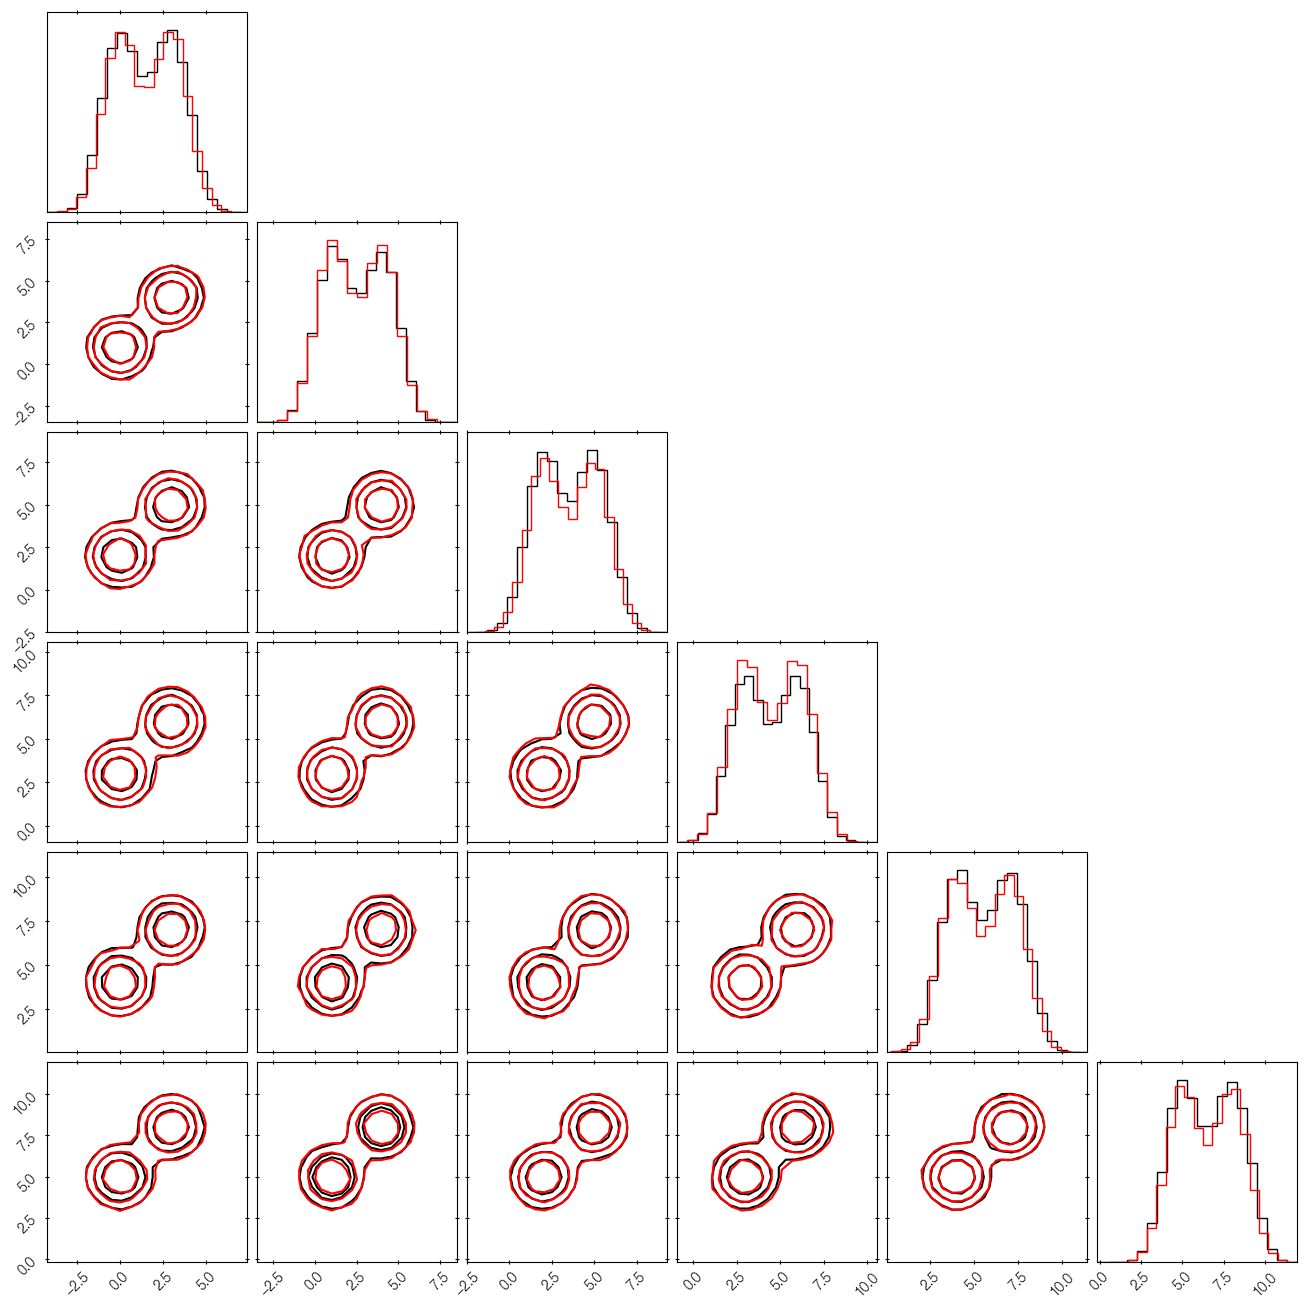

In [2]:
import matplotlib.pyplot as plt
import corner

t0 = time.time()
Y, _ = lgmm.sample(100000)
fig = corner.corner(Y, weights=np.ones(len(Y))/len(Y), plot_datapoints=False, plot_density=False, levels=[0.393, 0.675, 0.864])
corner.corner(X, weights=np.ones(len(X))/len(X), plot_datapoints=False, plot_density=False, levels=[0.393, 0.675, 0.864], fig=fig, color='red')
plt.savefig('plotcorner1.pdf')
print(f'sample + corner: {time.time() - t0:.2f}s')

This sampling approach is quite slow.

### Plotting with matplotlib

Next, we can plot the GMMs directly:

GMM plot: 0.84s


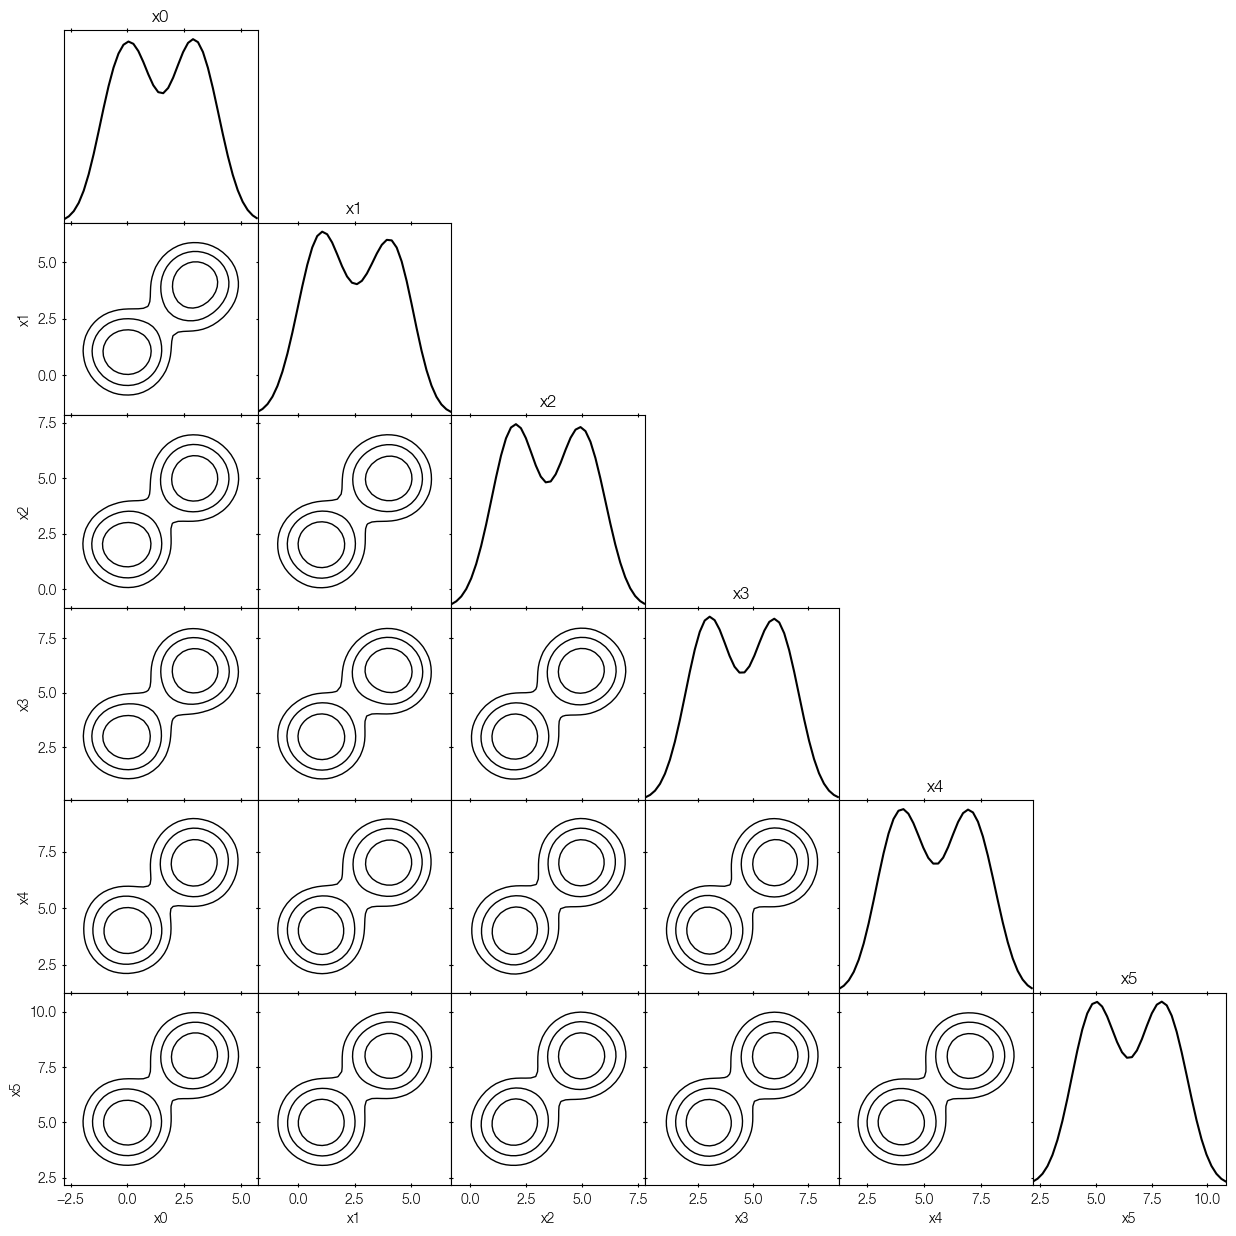

In [3]:
from askcarl.plot import plot_gmm_corner

t0 = time.time()
fig, axes = plot_gmm_corner(gmm, levels=[0.393, 0.675, 0.864])
plt.savefig('plotcorner.pdf')
print(f'GMM plot: {time.time() - t0:.2f}s')

Here is the API of this function: https://johannesbuchner.github.io/askcarl/askcarl.html#askcarl.plot.plot_gmm_corner

It behaves similarly to corner.py.

### Fast plotting with ReportLab

A much fast plot is possible by writing to a PDF directly instead
of rendering with matplotlib.

In [4]:
from askcarl.plot import plot_gmm_corner_pdf

t0 = time.time()
plot_gmm_corner_pdf('plotcorner_custom.pdf', gmm, levels=[0.393, 0.675, 0.864], scale=1.0)
print(f'custom corner pdf: {time.time() - t0:.2f}s')

custom corner pdf: 0.10s


Here is the output:

In [9]:
from IPython.display import IFrame
IFrame("plotcorner_custom.pdf", width=1000, height=500)

Here is the API of this very fast plotting function: https://johannesbuchner.github.io/askcarl/askcarl.html#askcarl.plot.plot_gmm_corner_pdf

Some reading of the ReportLab documentation (for colors and fonts) may be needed.